# **Used Cars Price Prediction**

## **Problem Definition**

### **The Context:**

 1. Build a robust and reliable data driven approach to predicting used car prices for a used car company. Data set consists car sales data from India.
 3. Value of a pre-owned vehicle can vary significantly based on factors like brand, model, mileage, miles on the car, its age, among other factors.
 4. If the company prices the car too high it won't sell. If it prices it too low will cut down profits.
 5. Right pricing will help the company be competitive.
 6. Developing the right model can help handle the volume of cars to be sold systematically based on data rather than manual guesses.
 7. Helps the company make faster data driven decisions.
 8. Can help improve the image of the company for its accurate and fair pricing by neither pricing too high nor pricing too low.
 9. Helps the company sell the cars in a timely manner potentially savings storage costs
 10. Being data driven will provide consistency!

### **The objective:**

 1. Use historical used car sales data to build a machine learning model which can accurately predict the price of a used car coming into the company's inventory.
 2. Move away from subjective and inconsistent pricing.
 3. Identify factors that have the greatest influence in pricing used cars.
 4. Come up with pricing that make sense and the model result should be interpretable.
 5. Use the model to predict prices faster.
 6. Help company make quick and consistent decision making.
 7. Price right, Sell quickly, Increase profits, Reduce inventory!

### **The key questions:**

1. What are the key factors that affect the used car pricing?
2. Is the quality of data good enough to build a model?
3. Are there missing values that needs to be addressed in the historical data?
4. Identify the machine learning model that best addresses the problem given the data available?
5. How do we measure model performance? What are the metrics that can be used?
6. How do we analyse the nature of individual attributes of the sales data, their correlations, outliers, distribution, etc.?

### **The problem formulation**:

1. Build a machine learning model that predicts reasonable price of any used car with high accuracy, based on the available historical data which is not perfect to start with.
2. Data science provides consistent, data driven approach to pricing an used car.
3. It helps analyse and identify the features that matters the most for the customers and help derive the right price.
4. It help address data quality issues, missing data, Incorrect values, Outliers by applying standarization, encoding, imputation and modeling.
5. Perform machine learning regression to predict continuous price values, minimize errors and help predict most accurate price possible for a used car.


### **Data Dictionary**

**S.No.** : Serial Number

**Name** : Name of the car which includes Brand name and Model name

**Location** : The location in which the car is being sold or is available for purchase (Cities)

**Year** : Manufacturing year of the car

**Kilometers_driven** : The total kilometers driven in the car by the previous owner(s) in KM

**Fuel_Type** : The type of fuel used by the car (Petrol, Diesel, Electric, CNG, LPG)

**Transmission** : The type of transmission used by the car (Automatic / Manual)

**Owner** : Type of ownership

**Mileage** : The standard mileage offered by the car company in kmpl or km/kg

**Engine** : The displacement volume of the engine in CC

**Power** : The maximum power of the engine in bhp

**Seats** : The number of seats in the car

**New_Price** : The price of a new car of the same model in INR 100,000

**Price** : The price of the used car in INR 100,000 (**Target Variable**)

### **Loading libraries**

In [ ]:
# Import the required libraries. Pandas handles tabular data, NumPy supports numerical operations, Matplotlib and Seaborn provide visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries to build linear model for prediction
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Import library to split arrays into random train and test subsets
from sklearn.model_selection import train_test_split

# Metrics to evaluate the model
from sklearn import metrics

# For tuning the model
from sklearn.model_selection import GridSearchCV

# Warnings are suppressed so non-critical library warnings do not clutter the notebook output.
import warnings
warnings.filterwarnings('ignore')

### **Let us load the data**

In [ ]:
# Import google colab drive module to connect google drive files
from google.colab import drive
drive.mount('/content/drive')
path="/content/drive/MyDrive/Colab Notebooks/Capstone/used_cars.csv"
# Loads data in csv file into a Pandas dataframe
data=pd.read_csv(path)
# By default displays first 5 rows of the dataset
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,8.61,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,NaN,17.74


## Data Overview

In [ ]:
# Describes the data frame data structure
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   float64
 9   Engine             7207 non-null   float64
 10  Power              7078 non-null   float64
 11  Seats              7200 non-null   float64
 12  New_price          1006 non-null   float64
 13  Price              6019 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 793.4+ KB


In [ ]:
# Count missing values
data.isnull().sum()

,0
S.No.,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,2
Engine,46


1. The dataset contains 7,253 rows and 14 columns.
2. It has 9 numeric and 5 categorical data columns.
3. Based on the data description, sample data, null value checks, we can see it requires feature engineering for missing value treatement, extract make and model from Name field for accurate and meaningful processing, encoding categorical data for modelling.

In [ ]:
# Remove S.No. column from data. Not useful for the data analysis
data.drop('S.No.', axis=1, inplace=True)

## **Exploratory Data Analysis**

In [ ]:
# Descriptive summary statistics of the dataFrame
data.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,New_price,Price
count,7253.000000,7.253000e+03,7251.000000,7207.000000,7078.000000,7200.000000,1006.000000,6019.000000
mean,2013.365366,5.869906e+04,18.141580,1616.573470,112.765214,5.280417,22.779692,9.479468
std,3.254421,8.442772e+04,4.562197,595.285137,53.493553,0.809277,27.759344,11.187917
min,1996.000000,1.710000e+02,0.000000,72.000000,34.200000,2.000000,3.910000,0.440000
25%,2011.000000,3.400000e+04,15.170000,1198.000000,75.000000,5.000000,7.885000,3.500000
50%,2014.000000,5.341600e+04,18.160000,1493.000000,94.000000,5.000000,11.570000,5.640000
75%,2016.000000,7.300000e+04,21.100000,1968.000000,138.100000,5.000000,26.042500,9.950000
max,2019.000000,6.500000e+06,33.540000,5998.000000,616.000000,10.000000,375.000000,160.000000


1. Considering the range of data for Year from 1996 to 2019, mean has a higher value which indicates most of the cars in the dataset are not too old. Also the 25 percentile is at the value of 2011 indicate the same.
2. KM driven has a extreme value of 6500000, which is unrealistic, indicating incorrect data. This data has high variability. Most of the cars are driven around and under 150000 KMs
3. Mileage has a minimum value of zero which needs to be imputed
4. From data.isnull().sum() we know missing value treatment required for Mileage, Engine, Power, Seats, New_price.
5. Statistics for many features indicate presence of outliers and skewed data distribution. (KM driven, Engine, Power, Price)

In [ ]:
# Descriptive summary of non-numeric, categorical data in the dataFrame
data.describe(include = ['object'])

,Name,Location,Fuel_Type,Transmission,Owner_Type
count,7253,7253,7253,7253,7253
unique,2041,11,5,2,4
top,Mahindra XUV500 W8 2WD,Mumbai,Diesel,Manual,First
freq,55,949,3852,5204,5952


In [ ]:
# Count of each unique value in all the categorical data columns
cat_cols = data.select_dtypes(include = ['object']).columns

for column in cat_cols:

    print("For column:", column)

    print(data[column].value_counts())

    print('-'*50)

For column: Name
Name
Mahindra XUV500 W8 2WD                   55
Maruti Swift VDI                         49
Maruti Swift Dzire VDI                   42
Honda City 1.5 S MT                      39
Maruti Swift VDI BSIV                    37
                                         ..
Mercedes-Benz E-Class E240 V6 AT          1
Nissan Terrano XE 85 PS                   1
Mahindra TUV 300 2015-2019 T8 AMT         1
Hyundai i20 2015-2017 1.4 CRDi Sportz     1
Hyundai Creta 1.6 VTVT Base               1
Name: count, Length: 2041, dtype: int64
--------------------------------------------------
For column: Location
Location
Mumbai        949
Hyderabad     876
Coimbatore    772
Kochi         772
Pune          765
Delhi         660
Kolkata       654
Chennai       591
Jaipur        499
Bangalore     440
Ahmedabad     275
Name: count, dtype: int64
--------------------------------------------------
For column: Fuel_Type
Fuel_Type
Diesel      3852
Petrol      3325
CNG           62
LPG           1

1. Name has 2041 unique values. Name contains both Brand and Model combined and it will be useful extract these data elements for more accurate pricing analysis.
2. Dataset includes 11 data from 11 cities with Mumbai topping the most used car sales data.
3. Fuel type is split between Petrol and Diesel, with Diesel cars higher in count.
4. Over 70% Manual tranmission cars and Over 80% are First Owners.


In [ ]:
# Sort the dataset in 'descending' order using the feature 'Kilometers_Driven'
data.sort_values('Kilometers_Driven', ascending = False).head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
2328,BMW X5 xDrive 30d M Sport,Chennai,2017,6500000,Diesel,Automatic,First,15.97,2993.0,258.00,5.0,NaN,65.0
340,Skoda Octavia Ambition Plus 2.0 TDI AT,Kolkata,2013,775000,Diesel,Automatic,First,19.30,1968.0,141.00,5.0,NaN,7.5
1860,Volkswagen Vento Diesel Highline,Chennai,2013,720000,Diesel,Manual,First,20.54,1598.0,103.60,5.0,NaN,5.9
358,Hyundai i10 Magna 1.2,Chennai,2009,620000,Petrol,Manual,First,20.36,1197.0,78.90,5.0,NaN,2.7
2823,Volkswagen Jetta 2013-2015 2.0L TDI Highline AT,Chennai,2015,480000,Diesel,Automatic,First,16.96,1968.0,138.03,5.0,NaN,13.0


In [ ]:
# Removing the 'row' at index 2328 from the data.
data.drop(index=2328, inplace=True)

In [ ]:
# Sort the dataset in 'ascending' order using the feature 'Mileage'
data.sort_values(by='Mileage').head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
3033,Hyundai Santro Xing XP,Jaipur,2005,120000,Petrol,Manual,First,0.0,1086.0,NaN,5.0,NaN,1.15
67,Mercedes-Benz C-Class Progressive C 220d,Coimbatore,2019,15369,Diesel,Automatic,First,0.0,1950.0,194.0,5.0,49.14,35.67
14,Land Rover Freelander 2 TD4 SE,Pune,2012,85000,Diesel,Automatic,Second,0.0,2179.0,115.0,5.0,NaN,17.50
749,Land Rover Range Rover 3.0 D,Mumbai,2008,55001,Diesel,Automatic,Second,0.0,NaN,NaN,NaN,NaN,26.50
3044,Hyundai Santro Xing GL,Kolkata,2009,60170,Petrol,Manual,First,0.0,1086.0,62.0,5.0,NaN,1.15


1. 0 Mileage indicates missing value needs data imputation
2. Also missing value treatment required for Engine, Power, Seats, New_price which contain null values.

## **Univariate Analysis**

In [ ]:
# checking columns that are numeric
data.select_dtypes(include="number").columns

Index(['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats',
       'New_price', 'Price'],
      dtype='object')

In [ ]:
# checking columns that are categorical
data.select_dtypes(include="object").columns

Index(['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type'], dtype='object')

Year
Skew : -0.84


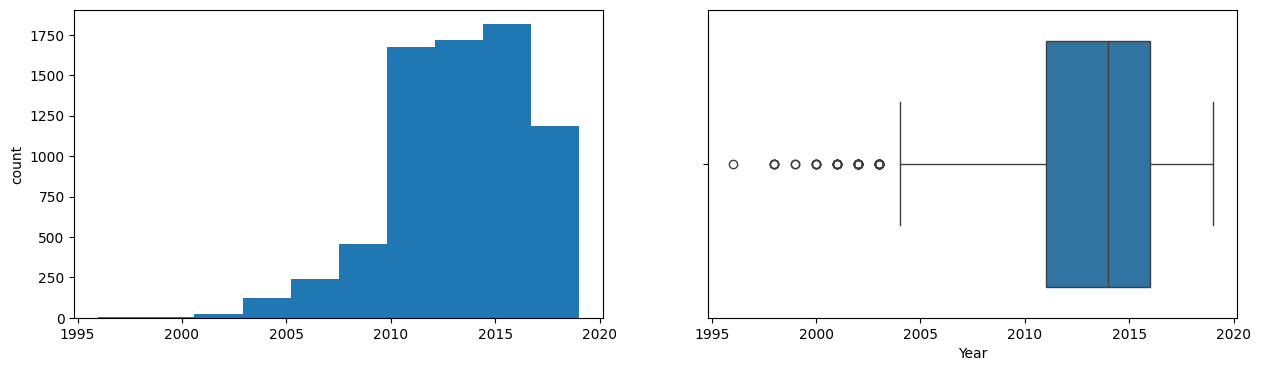

Kilometers_Driven
Skew : 3.83


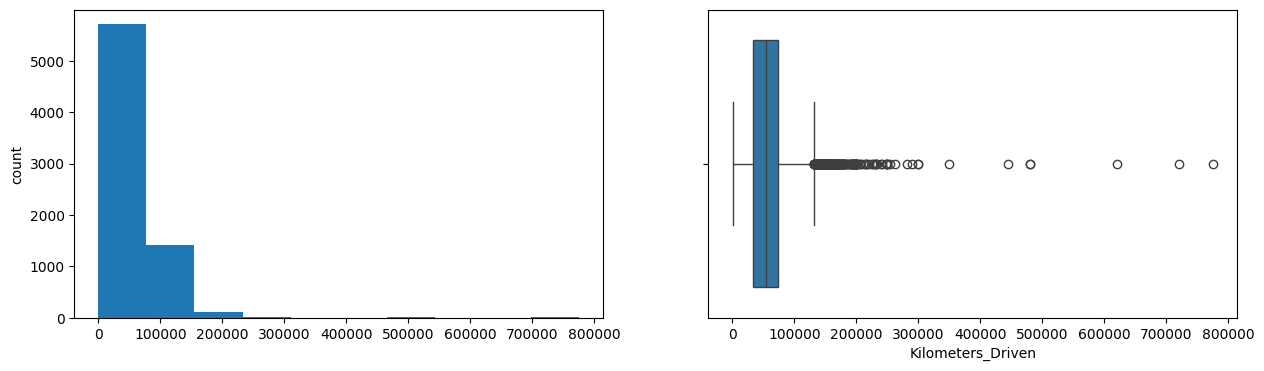

Mileage
Skew : -0.44


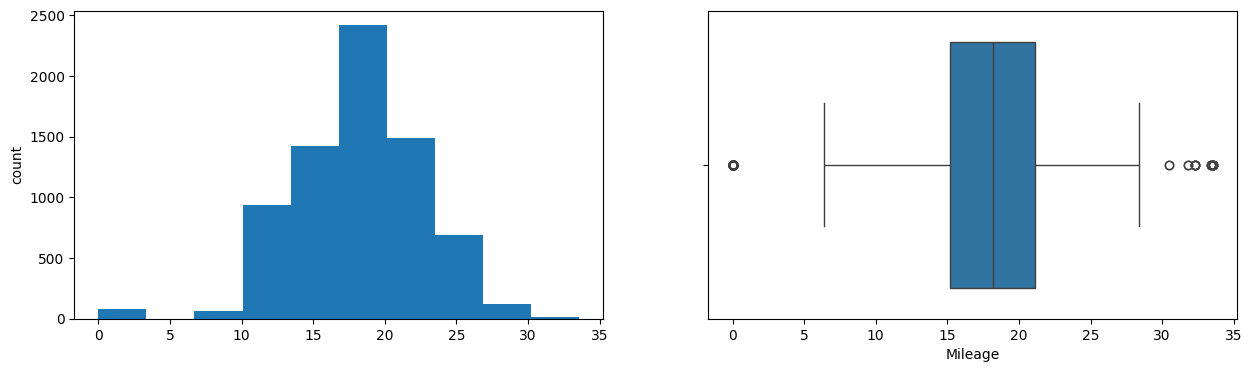

Engine
Skew : 1.41


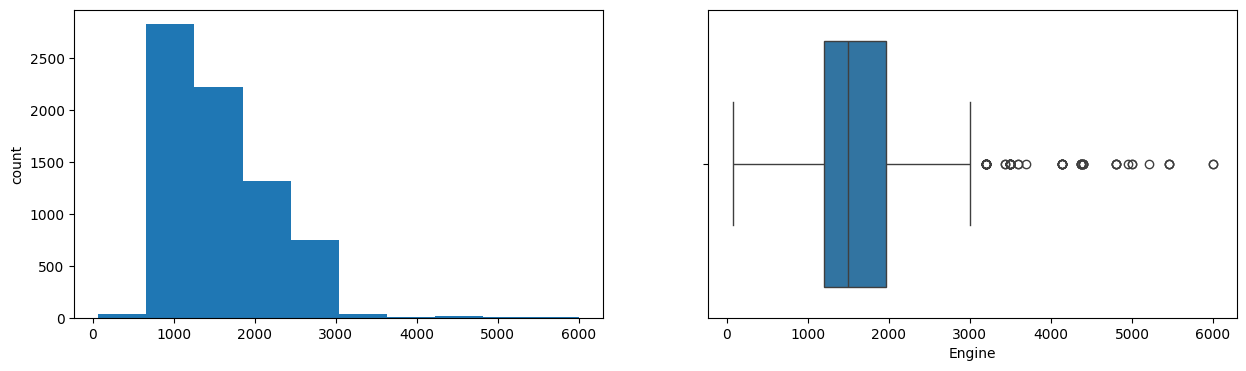

Power
Skew : 1.96


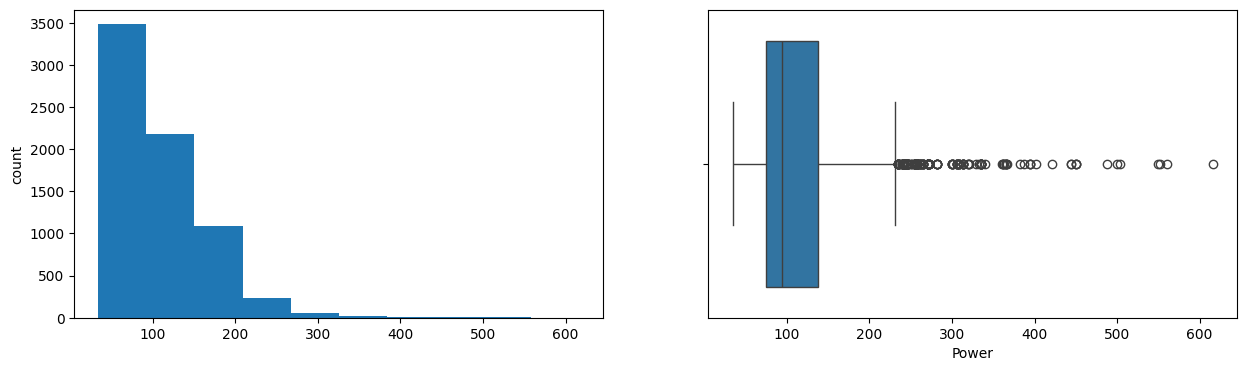

Seats
Skew : 1.95


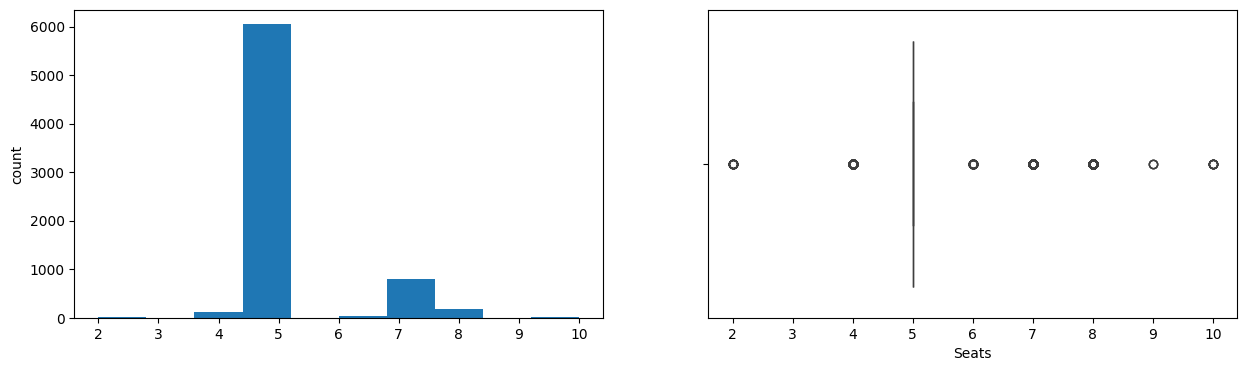

New_price
Skew : 4.13


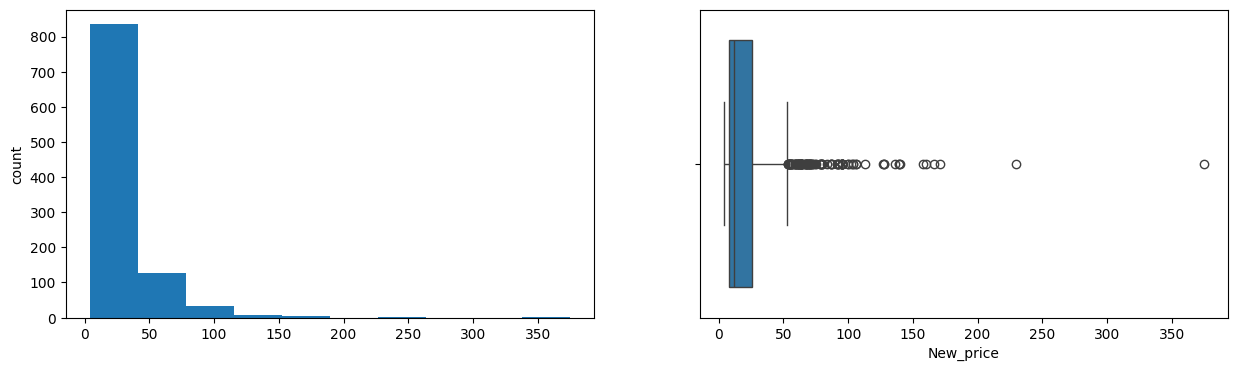

Price
Skew : 3.34


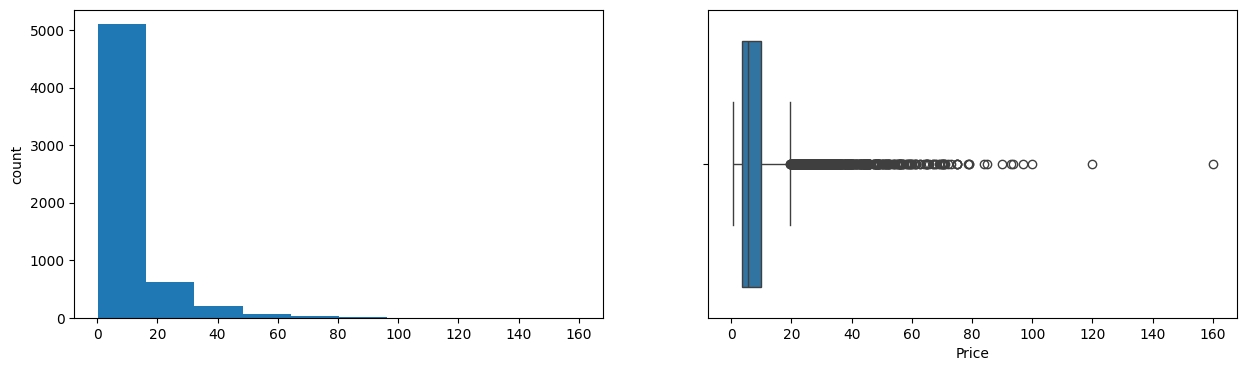

In [ ]:
# Examine the distribution and skewness of all the variables
# skew() measures asymmetry of the distribution.
# The histogram shows the shape of the variable.
# The boxplot highlights the median, spread, and potential outliers.
cols = list(data.select_dtypes(include="number").columns)

for col in cols:

    print(col)

    print('Skew :',round(data[col].skew(),2))

    plt.figure(figsize = (15, 4))

    plt.subplot(1, 2, 1)

    data[col].hist(bins = 10, grid = False)

    plt.ylabel('count')

    plt.subplot(1, 2, 2)

    sns.boxplot(x = data[col])

    plt.show()

1. KM Driven is extremely right skewed.
2. Price has a long tail because most of the cars are inexpensive compared to small number expensive cars.
3. New_price is strongly right skewed.
4. Power and Engine are moderately right skewed.
5. Year is left skewed as the dataset contains mostly recent year models.



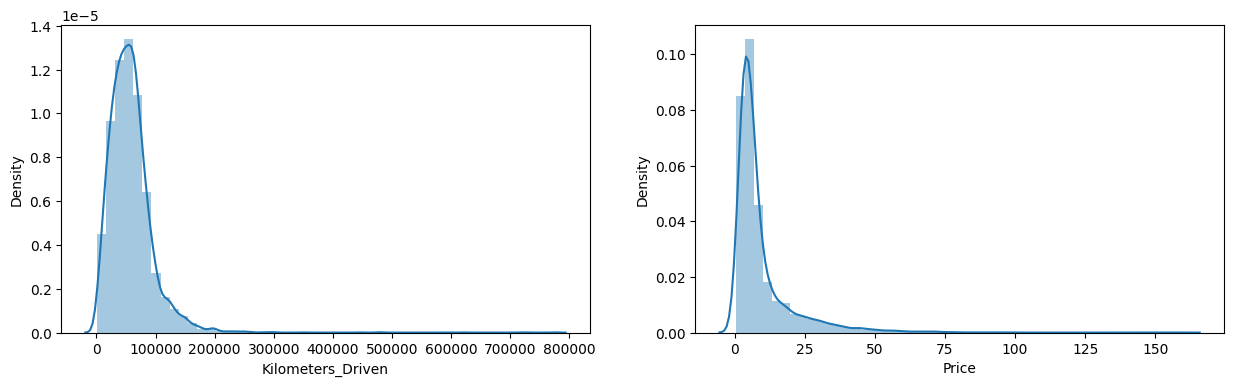

In [ ]:
# display the distribution plots side by side for KM drive and Prive variables
plt.figure(figsize = (15, 4))
plt.subplot(1, 2, 1)
sns.distplot(data["Kilometers_Driven"], axlabel = "Kilometers_Driven");
plt.subplot(1, 2, 2)
sns.distplot(data["Price"], axlabel = "Price");

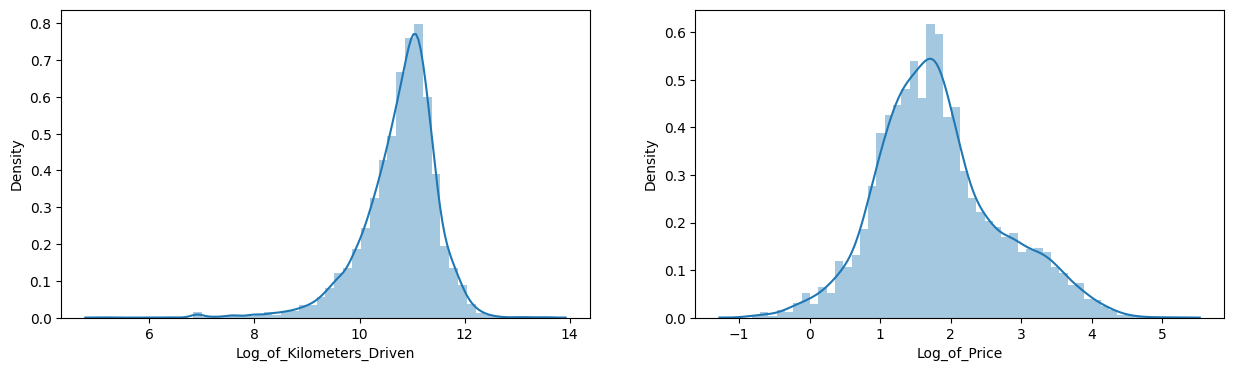

In [ ]:
#Applying log transformation and visualizing the data
data["Log_of_Kilometers_Driven"] = np.log(data["Kilometers_Driven"])
data["Log_of_Price"] = np.log(data["Price"])
plt.figure(figsize = (15, 4))
plt.subplot(1, 2, 1)
sns.distplot(data["Log_of_Kilometers_Driven"], axlabel = "Log_of_Kilometers_Driven");
plt.subplot(1, 2, 2)
sns.distplot(data["Log_of_Price"], axlabel = "Log_of_Price");

1. KM driven and Price are good candidates for log transformation. The log transformation substantially reduces the right skewness. After the transformation as seen from the graphs the distributions are more symmetric.

Year


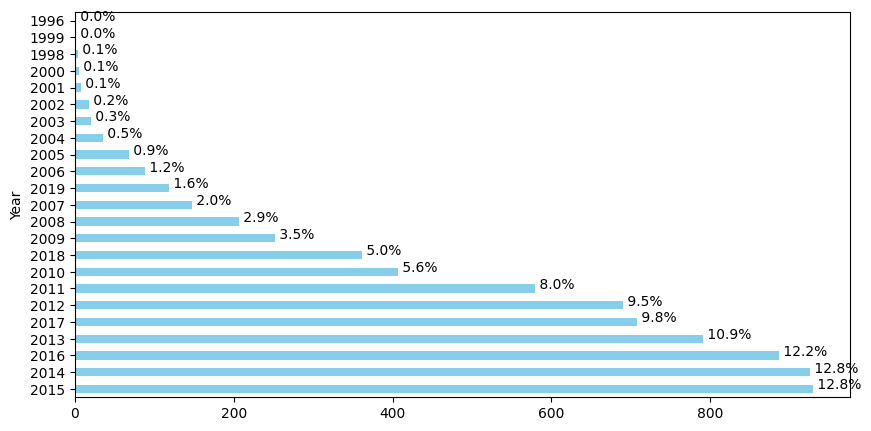

Location


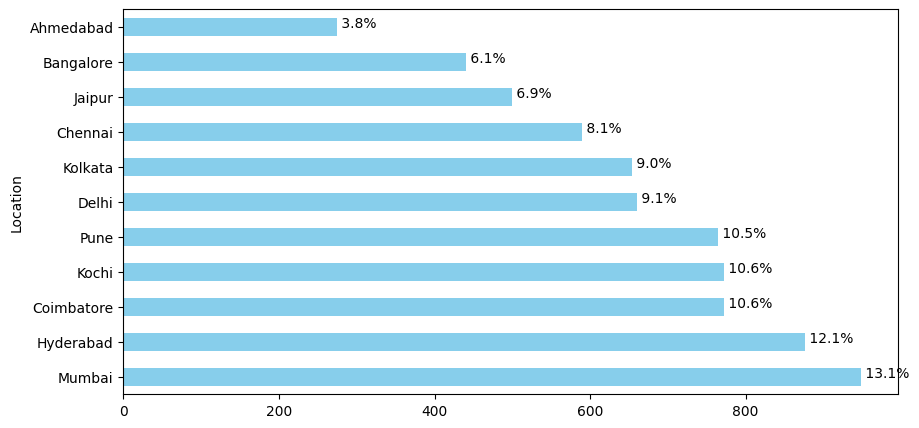

Fuel_Type


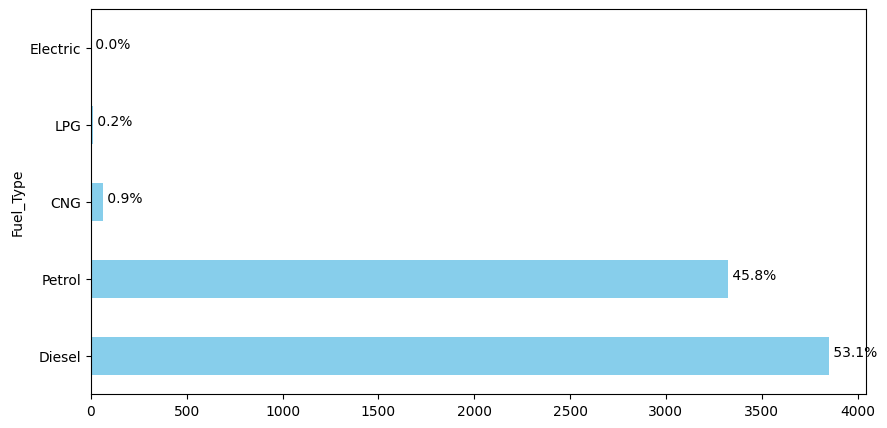

Transmission


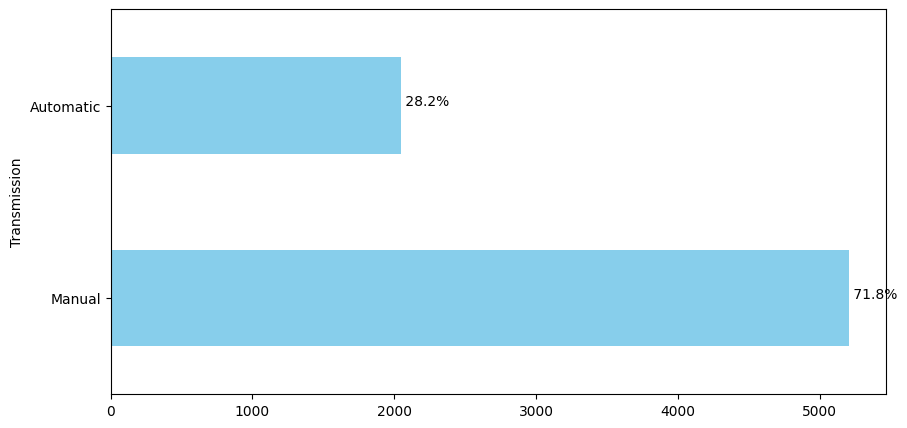

Owner_Type


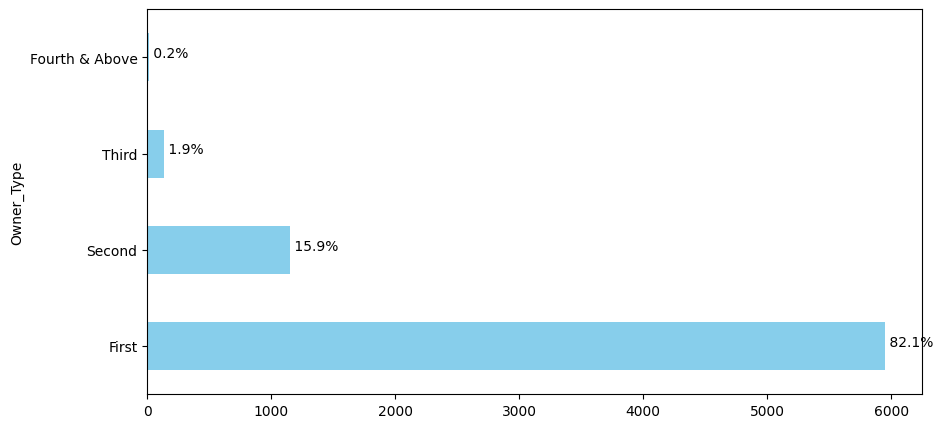

In [ ]:
# Examine the frequencies of all categorical variables using horizontal bar charts.
# Shows how many observations belong to each category, along with the percentage of the total.
cols = list(data.select_dtypes(include="object").columns)
cols.remove("Name")
cols.insert(0,"Year")

for col in cols:

    print(col)

    counts = data[col].value_counts()
    percentages = counts / counts.sum() * 100

    ax = counts.plot(kind="barh", color="skyblue", figsize=(10, 5))

    for i, (count, pct) in enumerate(zip(counts, percentages)):
        ax.text(count, i, f" {pct:.1f}%")
    plt.show()

1. Removed Name variable from visualisation as we know it has 2041 unique values. And we intend to extract brand and mode for more accurate modelling.
2. Mumbai has the most used car sales data while Ahmedabad has the lowest.
3. More than 50% car use Diesel as Fuel type.
4. Over 70% are Manual tranmission cars.
5. Over 80% are First Owners.

## **Bivariate Analysis**

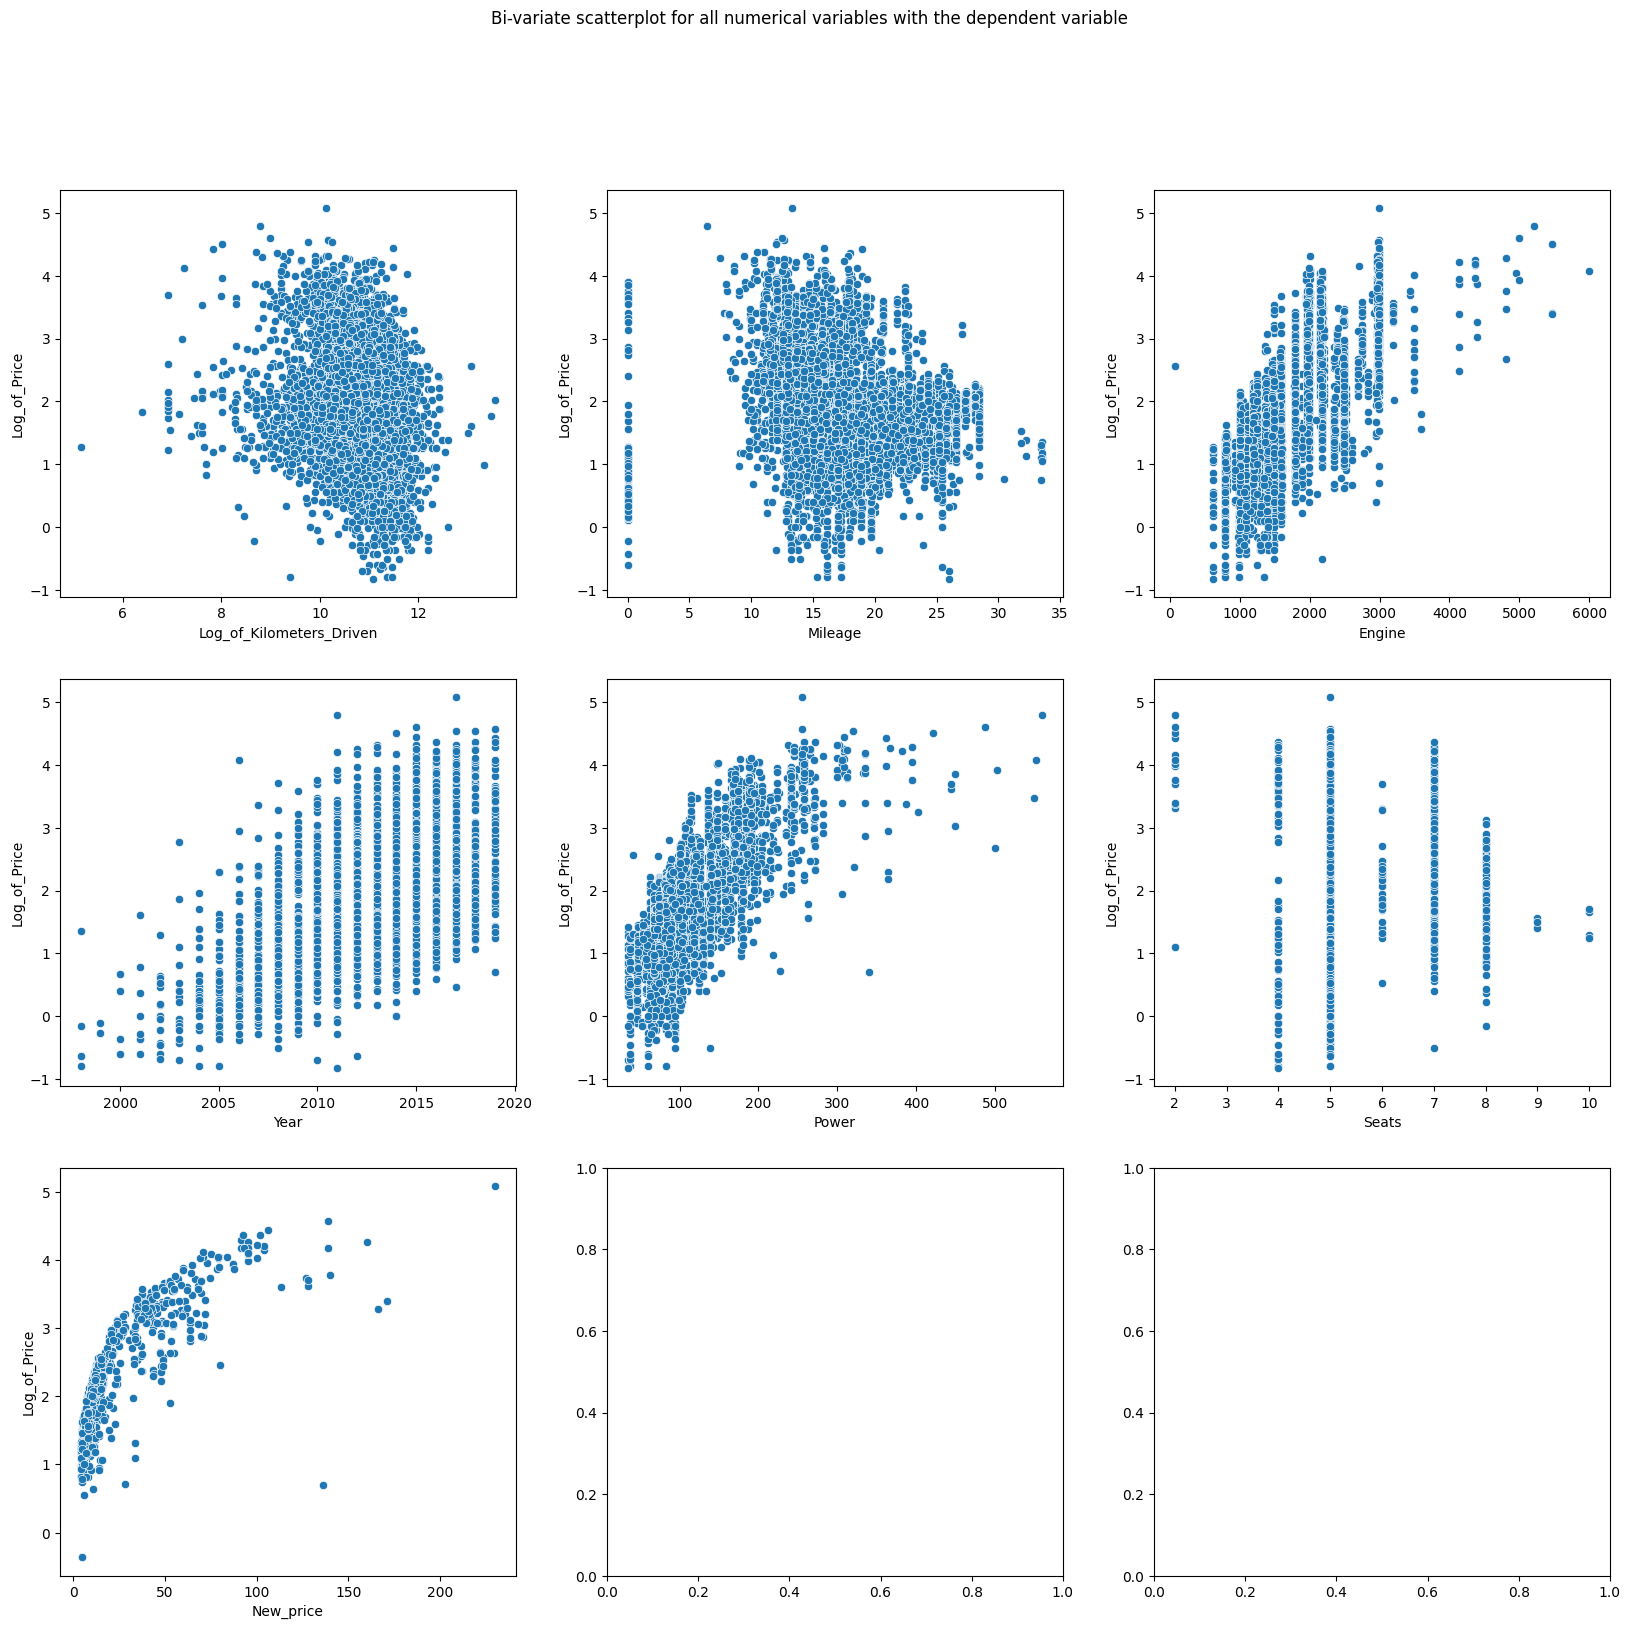

In [ ]:
# Bivariate analysis using Scatter plots display 3 charts in a row.
fig, axes = plt.subplots(3, 3, figsize = (20, 18))

fig.suptitle('Bi-variate scatterplot for all numerical variables with the dependent variable')

sns.scatterplot(x = 'Log_of_Kilometers_Driven', y = 'Log_of_Price', data = data, ax = axes[0,0]);

sns.scatterplot(x = 'Mileage', y = 'Log_of_Price', data = data, ax = axes[0,1]);

sns.scatterplot(x = 'Engine', y = 'Log_of_Price', data = data, ax = axes[0,2]);

sns.scatterplot(x = 'Year', y = 'Log_of_Price', data = data, ax = axes[1,0]);

sns.scatterplot(x = 'Power', y = 'Log_of_Price', data = data, ax = axes[1,1]);

sns.scatterplot(x = 'Seats', y = 'Log_of_Price', data = data, ax = axes[1,2]);

sns.scatterplot(x = 'New_price', y = 'Log_of_Price', data = data, ax = axes[2,0]);

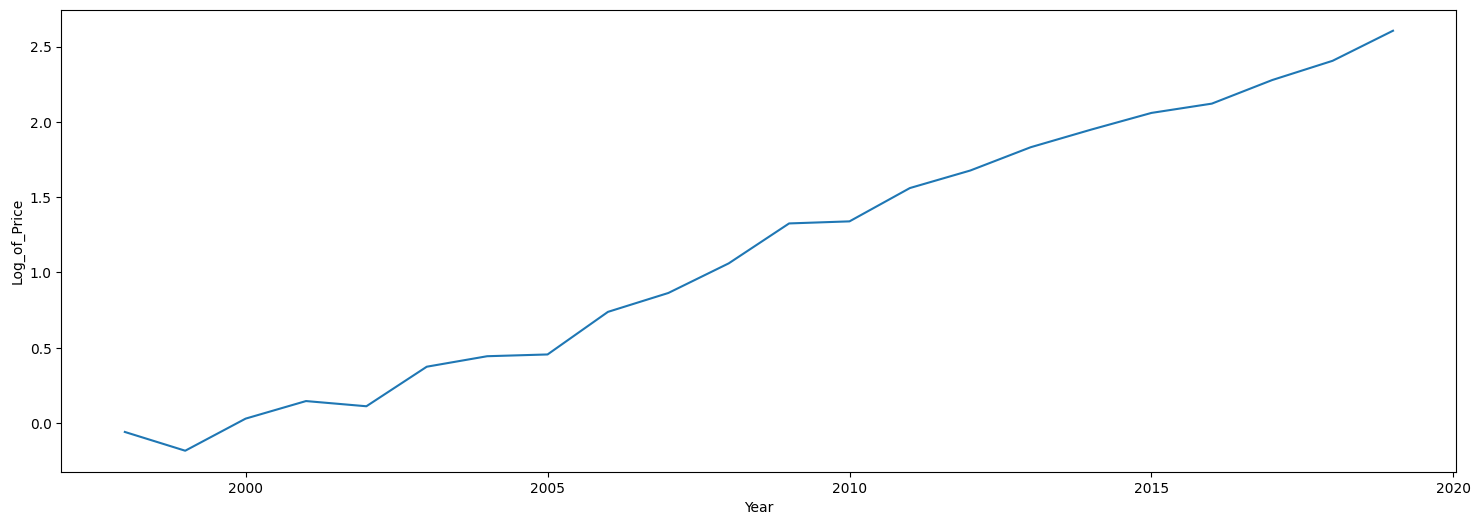

In [ ]:
#Lineplot to see Price of cars by model year
fig = plt.figure(figsize = (18, 6))

sns.lineplot(x = 'Year', y = 'Log_of_Price', data = data, ci = None, estimator = 'mean');

1. Very strong positive relationship between Price and New_Price, Price and Power. Higher power and higher showroom price for the cars indicates higher value for used cars.
2. Strong positive relationship between Price and Engine with larger capacity.
3. Newer(later year) model cars generally have higher resale prices than older cars
4. There is weak negative relationship between Price and KM driven.
5. No.of seats doesn't seem to have conclusive influence on Price.

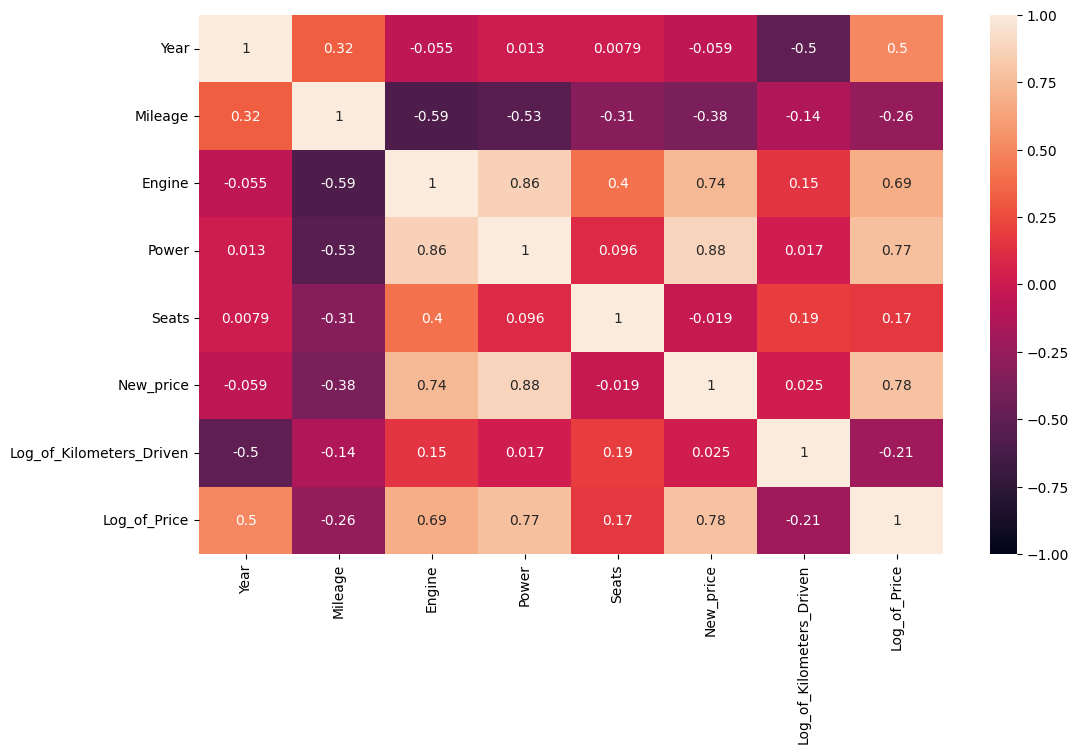

In [ ]:
# Check correlations between numerical variables.
# The correlation matrix measures the strength of linear relationships.
# sns.heatmap(..., annot=True) displays the correlations as a color-coded matrix and prints the numerical coefficients.
# Including the log transformation values and drop the original skewed data columns
plt.figure(figsize = (12, 7))

sns.heatmap(data.drop(["Kilometers_Driven", "Price"],axis = 1).corr(numeric_only = True), annot = True, vmin = -1, vmax = 1)

plt.show()

1. The correlation heatmap indicates that New_price, Power, Engine, and Year are the most influential numerical variables for predicting Price, while KM Drive has a moderate negative influence and Seats contribute very little in a linear relationship with price. Mileage has a moderate negative correlation with Price.

Year


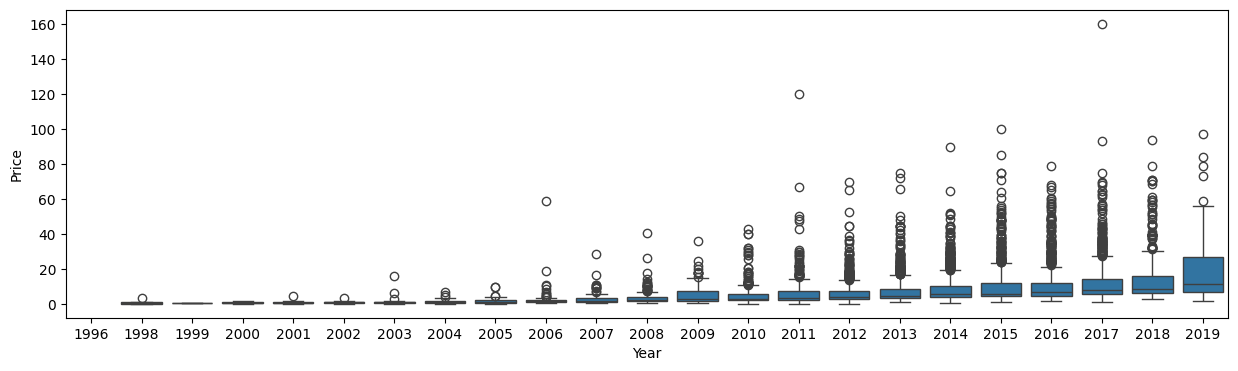

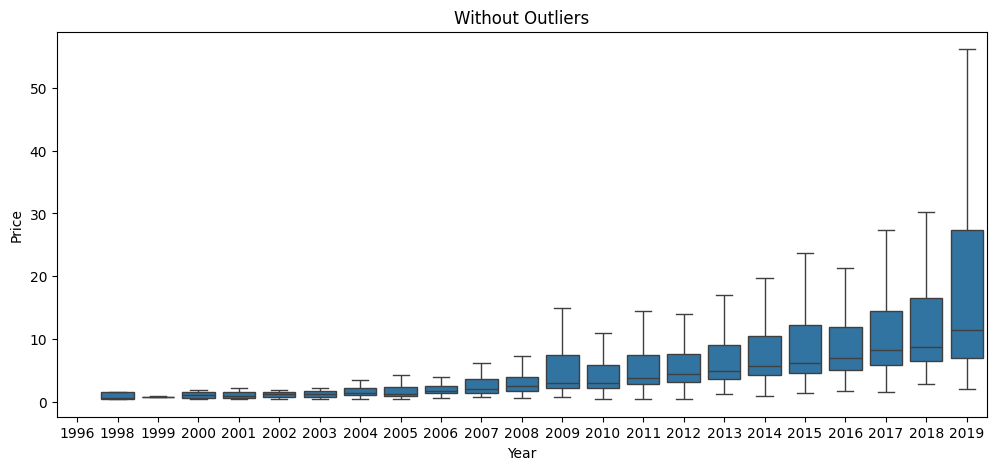

Location


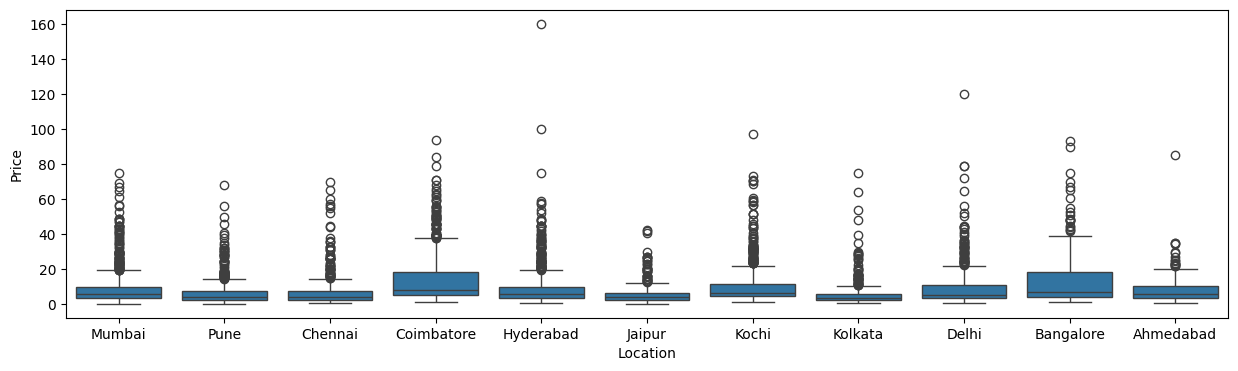

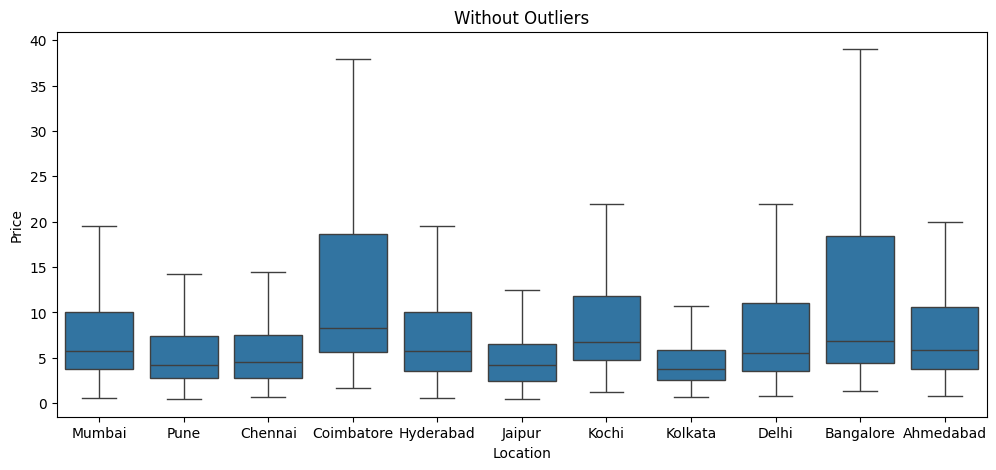

Fuel_Type


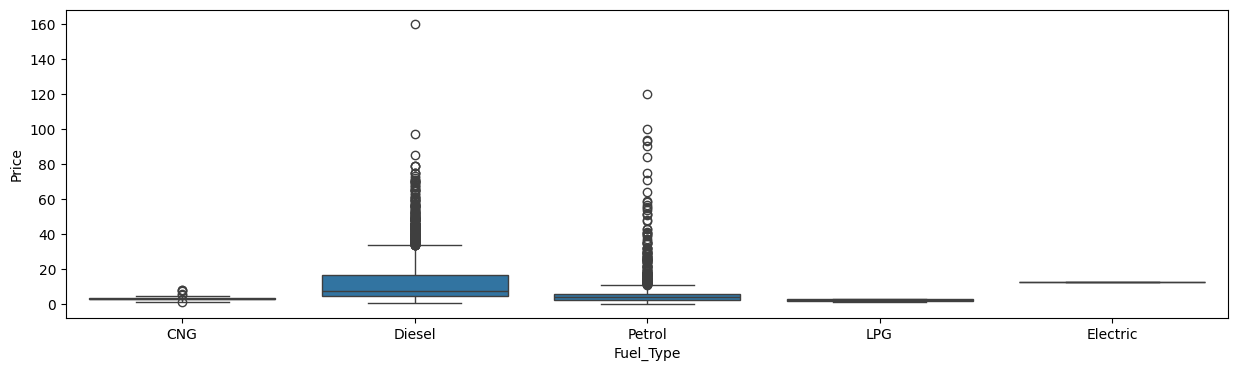

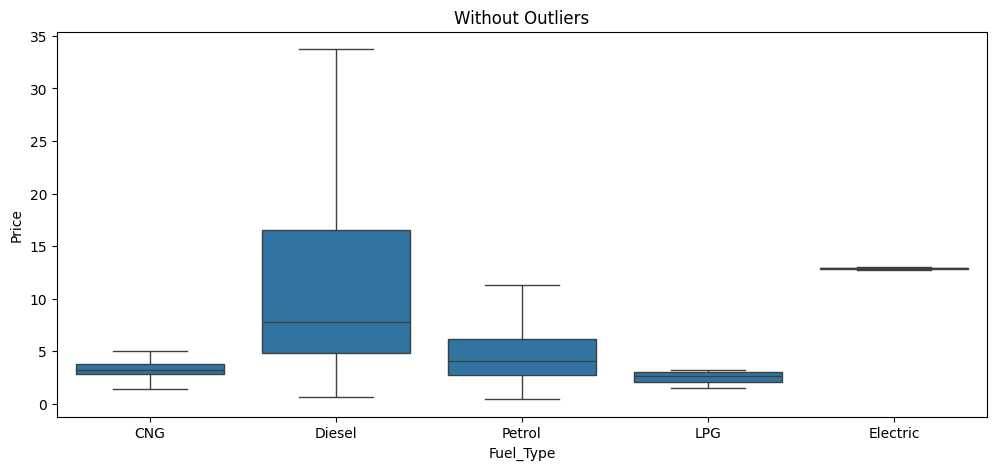

Transmission


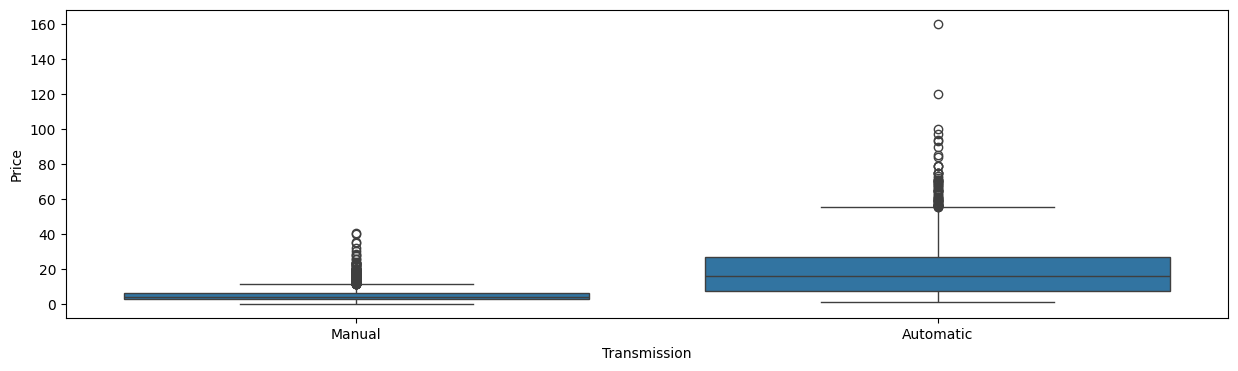

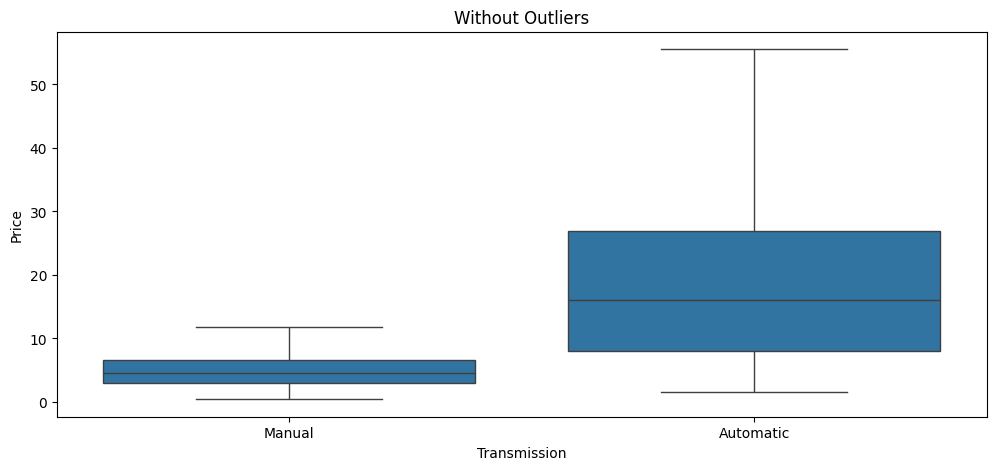

Owner_Type


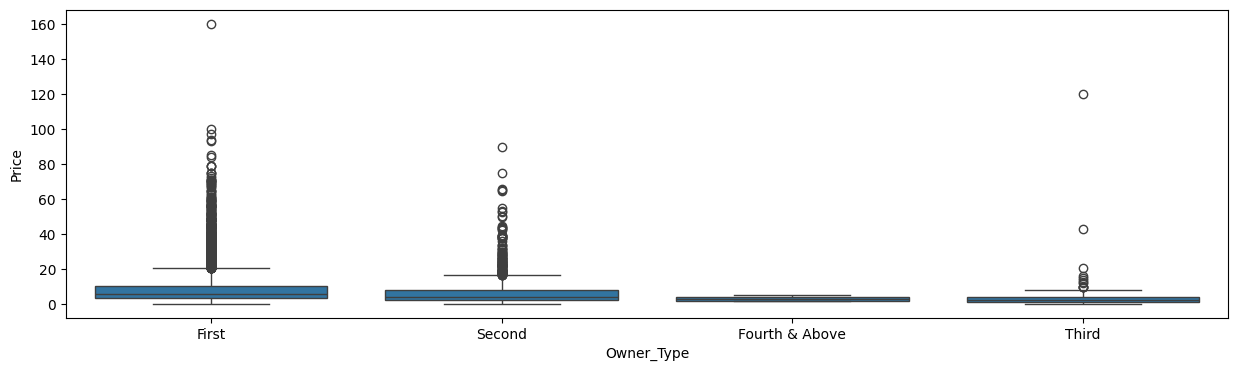

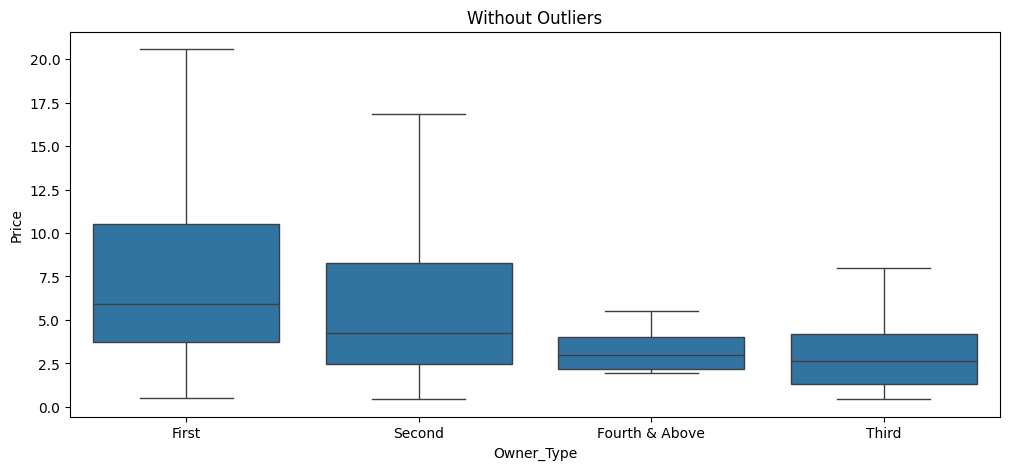

In [ ]:
# Create two set of boxplots for each variable: one with outliers and one without outliers to understand categorical variables influence in used-car Pricing

cols = list(data.select_dtypes(include="object").columns)
cols.remove("Name")
cols.insert(0,"Year")

for col in cols:

    print(col)

    plt.figure(figsize = (15, 4))

    sns.boxplot(x = data[col], y = data['Price'])

    plt.show()

    plt.figure(figsize = (12, 5))

    plt.title('Without Outliers')

    sns.boxplot(x = data[col], y = data['Price'], showfliers = False) # Turning off the outliers

    plt.show()

1. Box plot shows used car prices vary across different Locations. Some location show wider spread of prices, could be due to the type of cars. There are also several outliers across all Locations, especially on the higher price side. Also certain locations sell more cars. Location is definitely a very relevant and key independent variable, while type of cars(high end cars etc) and other factors seem to influence price variations within a Location. Used car prices vary significantly by city.
2. Later year, first owner and automatic transmission cars are clearly highly priced.
3. Diesel car prices are high compared to other fuel types

### **Feature Engineering**

In [ ]:
data["Name"].head()

,Name
0,Maruti Wagon R LXI CNG
1,Hyundai Creta 1.6 CRDi SX Option
2,Honda Jazz V
3,Maruti Ertiga VDI
4,Audi A4 New 2.0 TDI Multitronic


In [ ]:
data["Name"].nunique()

2041

In [ ]:
# Parsing out the brand and model values from the Name variable and add 2 additional columns
brands = data["Name"].str.split().str[0]
data["Brand"] = [x.lower() for x in brands]
models = data["Name"].str.split().str[1]
data["Model"] = [x.lower() for x in models]

print(data["Brand"].nunique())
print(data["Model"].nunique())

32
218


In [ ]:
data["Brand"].head()

,Brand
0,maruti
1,hyundai
2,honda
3,maruti
4,audi


In [ ]:
data["Model"].head()

,Model
0,wagon
1,creta
2,jazz
3,ertiga
4,a4


### **Missing value treatment**

In [ ]:
data.isnull().sum()

,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,2
Engine,46
Power,175


In [ ]:
(data["Mileage"]==0).sum()

np.int64(81)

In [ ]:
data[data["Mileage"]==0].head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price,Log_of_Kilometers_Driven,Log_of_Price,Brand,Model
14,Land Rover Freelander 2 TD4 SE,Pune,2012,85000,Diesel,Automatic,Second,0.0,2179.0,115.0,5.0,NaN,17.50,11.350407,2.862201,land,rover
67,Mercedes-Benz C-Class Progressive C 220d,Coimbatore,2019,15369,Diesel,Automatic,First,0.0,1950.0,194.0,5.0,49.14,35.67,9.640108,3.574310,mercedes-benz,c-class
79,Hyundai Santro Xing XL,Hyderabad,2005,87591,Petrol,Manual,First,0.0,1086.0,NaN,5.0,NaN,1.30,11.380434,0.262364,hyundai,santro
194,Honda City 1.5 GXI,Ahmedabad,2007,60006,Petrol,Manual,First,0.0,NaN,NaN,NaN,NaN,2.95,11.002200,1.081805,honda,city
229,Ford Figo Diesel,Bangalore,2015,70436,Diesel,Manual,First,0.0,1498.0,99.0,NaN,NaN,3.60,11.162460,1.280934,ford,figo


In [ ]:
# Calculate median mileage for each Brand and Model
median_mileage_zero = (
    data[data["Mileage"] > 0]                # keep only valid mileage values
        .groupby(["Brand", "Model"])["Mileage"]
        .median()
)
# Calculate median mileage at the Brand level
brand_median_mileage_zero = (
    data[data["Mileage"] > 0]
        .groupby("Brand")["Mileage"]
        .median()
)

In [ ]:
# Impute missing mileage values.
# Use the median mileage for each Brand and Model, if available.
# Otherwise, use the Brand-level median mileage.
# If neither is available, keep 0.

def fill_mileage_zero(row):
    if row["Mileage"] > 0:
        return row["Mileage"]

    key = (row["Brand"], row["Model"])
    if key in median_mileage_zero:
        return median_mileage_zero[key]

    # fallback to brand-level median
    if row["Brand"] in brand_median_mileage_zero:
        return brand_median_mileage_zero[row["Brand"]]

    return 0

data["Mileage"] = data.apply(fill_mileage_zero, axis=1)

In [ ]:
(data["Mileage"]==0).sum()

np.int64(1)

In [ ]:
data[data["Mileage"]==0].head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price,Log_of_Kilometers_Driven,Log_of_Price,Brand,Model
915,Smart Fortwo CDI AT,Pune,2008,103000,Diesel,Automatic,Second,0.0,799.0,NaN,2.0,NaN,3.0,11.542484,1.098612,smart,fortwo


In [ ]:
data[data["Name"].str.contains("Smart")]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price,Log_of_Kilometers_Driven,Log_of_Price,Brand,Model
915,Smart Fortwo CDI AT,Pune,2008,103000,Diesel,Automatic,Second,0.0,799.0,NaN,2.0,NaN,3.0,11.542484,1.098612,smart,fortwo


In [ ]:
# Removing the 'row' at index 915 from the data.
# Potentially old car Brand "Smart" from 2008 not available anymore. Only one record of this brand is found in the entire dataset and unable to impute meaningfully.
# Hence dropping the record.
data.drop(index=915, inplace=True)

In [ ]:
(data["Mileage"]==0).sum()

np.int64(0)

In [ ]:
data["Mileage"].isnull().sum()

np.int64(0)

In [ ]:
data[data["Seats"].isnull()].head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price,Log_of_Kilometers_Driven,Log_of_Price,Brand,Model
194,Honda City 1.5 GXI,Ahmedabad,2007,60006,Petrol,Manual,First,17.0,NaN,NaN,NaN,NaN,2.95,11.002200,1.081805,honda,city
208,Maruti Swift 1.3 VXi,Kolkata,2010,42001,Petrol,Manual,First,16.1,NaN,NaN,NaN,NaN,2.11,10.645449,0.746688,maruti,swift
229,Ford Figo Diesel,Bangalore,2015,70436,Diesel,Manual,First,20.0,1498.0,99.0,NaN,NaN,3.60,11.162460,1.280934,ford,figo
733,Maruti Swift 1.3 VXi,Chennai,2006,97800,Petrol,Manual,Third,16.1,NaN,NaN,NaN,NaN,1.75,11.490680,0.559616,maruti,swift
749,Land Rover Range Rover 3.0 D,Mumbai,2008,55001,Diesel,Automatic,Second,12.7,NaN,NaN,NaN,NaN,26.50,10.915107,3.277145,land,rover


In [ ]:
# Calculate median seats for each Brand and Model
median_seats = (
    data.dropna(subset=["Seats"])
        .groupby(["Brand", "Model"])["Seats"]
        .median()
)

# Calculate median seats at the Brand level
brand_median_seats = (
    data.dropna(subset=["Seats"])
        .groupby("Brand")["Seats"]
        .median()
)

In [ ]:
data["Seats"].isnull().sum()

np.int64(53)

In [ ]:
# Impute missing seats values.
# Use the median seats for each Brand and Model, if available.
# Otherwise, use the Brand-level median seats.
# If neither is available, keep 0.
def fill_seats(row):
    if pd.notnull(row["Seats"]):
        return row["Seats"]

    key = (row["Brand"], row["Model"])
    if key in median_seats:
        return median_seats[key]

    # fallback to brand-level median
    if row["Brand"] in brand_median_seats:
        return brand_median_seats[row["Brand"]]

    return None

data["Seats"] = data.apply(fill_seats, axis=1)

In [ ]:
data[data["Seats"].isnull()]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price,Log_of_Kilometers_Driven,Log_of_Price,Brand,Model


In [ ]:
data["New_price"].isnull().sum()

np.int64(6245)

In [ ]:
# Calculate median newprice for each Brand and Model
median_newprice = (
    data.dropna(subset=["New_price"])
        .groupby(["Brand", "Model"])["New_price"]
        .median()
)
# Calculate median newprice at the Brand level
brand_median_newprice = (
    data.dropna(subset=["New_price"])
        .groupby("Brand")["New_price"]
        .median()
)

In [ ]:
# Impute missing newprice values.
# Use the median newprice for each Brand and Model, if available.
# Otherwise, use the Brand-level median newprice.
# If neither is available, keep 0.
def fill_newprice(row):
    if pd.notnull(row["New_price"]):
        return row["New_price"]

    key = (row["Brand"], row["Model"])
    if key in median_newprice:
        return median_newprice[key]

    # fallback to brand-level median
    if row["Brand"] in brand_median_newprice:
        return brand_median_newprice[row["Brand"]]

    return None

data["New_price"] = data.apply(fill_newprice, axis=1)

In [ ]:
data["New_price"].isnull().sum()

np.int64(158)

In [ ]:
data[data["New_price"].isnull()].head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price,Log_of_Kilometers_Driven,Log_of_Price,Brand,Model
145,Chevrolet Beat LT Option,Pune,2014,38800,Petrol,Manual,First,18.60,1199.0,76.8,5.0,NaN,2.85,10.566176,1.047319,chevrolet,beat
179,Chevrolet Beat Diesel LT,Jaipur,2012,88000,Diesel,Manual,First,25.44,936.0,57.6,5.0,NaN,1.50,11.385092,0.405465,chevrolet,beat
183,Chevrolet Optra Magnum 1.6 LS BS3,Jaipur,2007,118500,Petrol,Manual,First,12.90,1598.0,102.5,5.0,NaN,1.25,11.682668,0.223144,chevrolet,optra
231,Chevrolet Beat LT,Kochi,2016,60813,Petrol,Manual,Second,18.60,1199.0,76.8,5.0,NaN,3.32,11.015559,1.199965,chevrolet,beat
240,Chevrolet Beat Diesel LT,Mumbai,2013,74000,Diesel,Manual,First,25.44,936.0,57.6,5.0,NaN,2.65,11.211820,0.974560,chevrolet,beat


In [ ]:
data[(data["Name"].str.contains("Chevrolet Beat")) & (data["Fuel_Type"] == "Petrol")]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price,Log_of_Kilometers_Driven,Log_of_Price,Brand,Model
145,Chevrolet Beat LT Option,Pune,2014,38800,Petrol,Manual,First,18.6,1199.0,76.8,5.0,NaN,2.85,10.566176,1.047319,chevrolet,beat
231,Chevrolet Beat LT,Kochi,2016,60813,Petrol,Manual,Second,18.6,1199.0,76.8,5.0,NaN,3.32,11.015559,1.199965,chevrolet,beat
502,Chevrolet Beat LS,Kochi,2012,32717,Petrol,Manual,First,18.6,1199.0,79.4,5.0,NaN,2.55,10.395650,0.936093,chevrolet,beat
522,Chevrolet Beat LT,Pune,2014,8700,Petrol,Manual,First,18.6,1199.0,76.8,5.0,NaN,2.55,9.071078,0.936093,chevrolet,beat
646,Chevrolet Beat Option Pack,Kolkata,2010,35000,Petrol,Manual,Second,18.6,1199.0,79.4,5.0,NaN,1.50,10.463103,0.405465,chevrolet,beat
779,Chevrolet Beat LS,Kolkata,2010,17088,Petrol,Manual,First,18.6,1199.0,79.4,5.0,NaN,1.46,9.746132,0.378436,chevrolet,beat
1087,Chevrolet Beat LS,Kolkata,2015,120000,Petrol,Manual,First,18.6,1199.0,76.8,5.0,NaN,2.50,11.695247,0.916291,chevrolet,beat
1229,Chevrolet Beat LT,Pune,2012,78000,Petrol,Manual,Second,18.6,1199.0,79.4,5.0,NaN,2.00,11.264464,0.693147,chevrolet,beat
1285,Chevrolet Beat LS,Pune,2012,65000,Petrol,Manual,First,18.6,1199.0,79.4,5.0,NaN,2.50,11.082143,0.916291,chevrolet,beat
1422,Chevrolet Beat LT,Mumbai,2014,54890,Petrol,Manual,Second,17.8,1199.0,76.8,5.0,NaN,2.45,10.913086,0.896088,chevrolet,beat


In [ ]:
((data["Name"].str.contains("Chevrolet Beat")) & (data["Fuel_Type"] == "Petrol")).sum()

np.int64(29)

In [ ]:
# Total no.of cars that are Chevrolet
data["Name"].str.contains("Chevrolet").sum()

np.int64(151)

In [ ]:
# All Chevrolet cars regardless of the model doesn't have a new price.
((data["Name"].str.contains("Chevrolet")) & data["New_price"].isnull()).sum()

np.int64(151)

In [ ]:
# There is no reference new price to impute for Chevrolet cars. Hence dropping those records
filter = (data["Name"].str.contains("Chevrolet")) & data["New_price"].isnull()
data.drop(data[filter].index, inplace=True)
((data["Name"].str.contains("Chevrolet")) & data["New_price"].isnull()).sum()

np.int64(0)

In [ ]:
data["New_price"].isnull().sum()

np.int64(7)

In [ ]:
data[data["New_price"].isnull()]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price,Log_of_Kilometers_Driven,Log_of_Price,Brand,Model
1221,Ambassador Classic Nova Diesel,Chennai,2003,80000,Diesel,Manual,Third,12.8,1489.0,35.50,5.0,NaN,1.35,11.289782,0.300105,ambassador,classic
4997,Force One LX 4x4,Chennai,2014,50000,Diesel,Manual,First,17.0,2200.0,139.01,7.0,NaN,12.00,10.819778,2.484907,force,one
5182,Force One LX ABS 7 Seating,Kolkata,2014,41000,Diesel,Manual,First,17.0,2149.0,139.07,7.0,NaN,8.00,10.621327,2.079442,force,one
5206,Force One LX 4x4,Kolkata,2014,41000,Diesel,Manual,First,17.0,2200.0,139.01,7.0,NaN,8.00,10.621327,2.079442,force,one
5781,Lamborghini Gallardo Coupe,Delhi,2011,6500,Petrol,Automatic,Third,6.4,5204.0,560.00,2.0,NaN,120.00,8.779557,4.787492,lamborghini,gallardo
6216,Hindustan Motors Contessa 2.0 DSL,Pune,1996,65000,Diesel,Manual,Second,14.1,1995.0,NaN,5.0,NaN,NaN,11.082143,NaN,hindustan,motors
7067,OpelCorsa 1.4Gsi,Hyderabad,2005,50000,Petrol,Manual,Second,14.2,1389.0,88.00,5.0,NaN,NaN,10.819778,NaN,opelcorsa,1.4gsi


In [ ]:
# 7 Cars listed above are brands that has 1 or very few cars of that brand. There is no reference new price value to impute. Hence dropping the 7 records.
data["Name"].str.contains("Opel").sum()

np.int64(1)

In [ ]:
data["Name"].str.contains("Hindustan").sum()

np.int64(1)

In [ ]:
data["Name"].str.contains("Lamborghini").sum()

np.int64(1)

In [ ]:
data["Name"].str.contains("Ambassador").sum()

np.int64(1)

In [ ]:
data["Name"].str.contains("Force").sum()

np.int64(3)

In [ ]:
filter2 = data["New_price"].isnull()
data.drop(data[filter2].index, inplace=True)
data["New_price"].isnull().sum()

np.int64(0)

In [ ]:
data["Price"].isnull().sum()

np.int64(1202)

In [ ]:
# Drop the rows where Price is null
filter3 = data["Price"].isnull()
data.drop(data[filter3].index, inplace=True)
data["Price"].isnull().sum()

np.int64(0)

In [ ]:
data["Engine"].isnull().sum()

np.int64(36)

In [ ]:
# Calculate median engine value for each Brand and Model
median_engine = (
    data.dropna(subset=["Engine"])
        .groupby(["Brand", "Model"])["Engine"]
        .median()
)

# Calculate median engine value at the Brand level
brand_median_engine = (
    data.dropna(subset=["Engine"])
        .groupby("Brand")["Engine"]
        .median()
)

In [ ]:
# Impute missing engine values.
# Use the median engine value for each Brand and Model, if available.
# Otherwise, use the Brand-level median engine value.
# If neither is available, keep 0.
def fill_newengine(row):
    if pd.notnull(row["Engine"]):
        return row["Engine"]

    key = (row["Brand"], row["Model"])
    if key in median_engine:
        return median_engine[key]

    # fallback to brand-level median
    if row["Brand"] in brand_median_engine:
        return brand_median_engine[row["Brand"]]

    return None

data["Engine"] = data.apply(fill_newengine, axis=1)

In [ ]:
data["Engine"].isnull().sum()

np.int64(0)

In [ ]:
data["Power"].isnull().sum()

np.int64(141)

In [ ]:
# Calculate median power for each Brand and Model
median_power = (
    data.dropna(subset=["Power"])
        .groupby(["Brand", "Model"])["Power"]
        .median()
)
# Calculate median power at the Brand level
brand_median_power = (
    data.dropna(subset=["Power"])
        .groupby("Brand")["Power"]
        .median()
)

In [ ]:
# Impute missing power values.
# Use the median power for each Brand and Model, if available.
# Otherwise, use the Brand-level median power.
# If neither is available, keep 0.
def fill_newpower(row):
    if pd.notnull(row["Power"]):
        return row["Power"]

    key = (row["Brand"], row["Model"])
    if key in median_power:
        return median_power[key]

    # fallback to brand-level median
    if row["Brand"] in brand_median_power:
        return brand_median_power[row["Brand"]]

    return None

data["Power"] = data.apply(fill_newpower, axis=1)

In [ ]:
data["Power"].isnull().sum()

np.int64(0)

In [ ]:
data.isnull().sum()

,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,0
Engine,0
Power,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5891 entries, 0 to 6017
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Name                      5891 non-null   object 
 1   Location                  5891 non-null   object 
 2   Year                      5891 non-null   int64  
 3   Kilometers_Driven         5891 non-null   int64  
 4   Fuel_Type                 5891 non-null   object 
 5   Transmission              5891 non-null   object 
 6   Owner_Type                5891 non-null   object 
 7   Mileage                   5891 non-null   float64
 8   Engine                    5891 non-null   float64
 9   Power                     5891 non-null   float64
 10  Seats                     5891 non-null   float64
 11  New_price                 5891 non-null   float64
 12  Price                     5891 non-null   float64
 13  Log_of_Kilometers_Driven  5891 non-null   float64
 14  Log_of_Price 

In [ ]:
data.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,New_price,Price,Log_of_Kilometers_Driven,Log_of_Price
count,5891.000000,5891.000000,5891.000000,5891.000000,5891.000000,5891.000000,5891.000000,5891.000000,5891.000000,5891.000000
mean,2013.397046,57561.879817,18.313999,1624.519946,113.017780,5.278391,21.826039,9.586011,10.754874,1.842135
std,3.268627,37993.874016,4.173192,600.829243,53.725153,0.797645,25.107064,11.150884,0.715162,0.869374
min,1998.000000,171.000000,7.500000,72.000000,34.200000,2.000000,3.910000,0.440000,5.141664,-0.820981
25%,2012.000000,33727.500000,15.290000,1198.000000,74.000000,5.000000,7.880000,3.500000,10.426069,1.252763
50%,2014.000000,53000.000000,18.160000,1495.000000,94.000000,5.000000,11.145000,5.750000,10.878047,1.749200
75%,2016.000000,72670.000000,21.100000,1984.000000,138.100000,5.000000,24.010000,10.110000,11.193684,2.313525
max,2019.000000,775000.000000,33.540000,5998.000000,552.000000,10.000000,375.000000,160.000000,13.560618,5.075174


## **Important Insights from EDA and Data Preprocessing**

1. The dataset contains mostly recent cars, with several numerical variables showing strong right skewness and significant outliers.
2. Missing values are present in Mileage, Engine, Power, Seats, and New_price.
3. Categorical variables show realistic market patterns: Diesel and Manual cars dominate, and most cars are first owners.
4. Log transformation is essential for KM Driven and Price to make the distribution more symettrical
5. Correlation analysis indicates that New_price, Power, Engine, and Year are the strongest predictors used car pricing.
6. Category wise analysis confirms that newer, first owner, automatic, and diesel cars command higher resale value.
7. Parsed out brand and model values as 2 columns from the Name variable.
8. Variable mileage, engine, seats, newprice, power needed missing value imputation. It was done based on calculated median values for each Brand and Model, if available or the calculated median values at the Brand level. Few records were dropped as the values couldn't be imputed. For eg: 7 rows for car brands Opel, Hindustan, Ambassador, Lamborghini, Force.




## **Building Various Models**


1. What we want to predict is the "Price". We will use the normalized version 'price_log' for modeling.
2. Before we proceed to the model, we'll have to encode categorical features. We will drop categorical features like Name.
3. We'll split the data into train and test, to be able to evaluate the model that we build on the train data.
4. Build Regression models using train data.
5. Evaluate the model performance.

### **Split the Data**

In [ ]:
# Prepare independent(X) and dependent variables(y)
X = data.drop(['Name','Price','Log_of_Price','Kilometers_Driven'], axis = 1)

y = data[["Log_of_Price", "Price"]]

In [ ]:
# Convert categorical text data into numbers. Remove first category column to prevent redundancy.
X = pd.get_dummies(X, drop_first = True)

In [ ]:
# Splitting data into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

print(X_train.shape, X_test.shape)

(4123, 247) (1768, 247)


In [ ]:
# Function to calculate r2_score and RMSE on train and test data.
# Takes model that was trained on the training data set and returns R square and RMSE scores on training and test datasets

def get_model_score(model, flag = True):

    score_list = []

    pred_train = model.predict(X_train)

    pred_train_ = np.exp(pred_train) # convert log predictions back to actual prices

    pred_test = model.predict(X_test)

    pred_test_ = np.exp(pred_test) # convert log predictions back to actual prices

    # Calculating R Squared train and test scores
    train_r2 = metrics.r2_score(y_train['Price'], pred_train_)
    test_r2 = metrics.r2_score(y_test['Price'], pred_test_)

    # Calculating Root Mean Square Error(RMSE) train and test scores
    train_rmse = np.sqrt(metrics.mean_squared_error(y_train['Price'], pred_train_))
    test_rmse = np.sqrt(metrics.mean_squared_error(y_test['Price'], pred_test_))

    score_list.extend((train_r2, test_r2, train_rmse, test_rmse))

    # If the flag is set to True then only the following print statements will be dispayed, the default value is True
    if flag == True:

        print("R-square on training set : ", metrics.r2_score(y_train['Price'], pred_train_))

        print("R-square on test set : ", metrics.r2_score(y_test['Price'], pred_test_))

        print("RMSE on training set : ", np.sqrt(metrics.mean_squared_error(y_train['Price'], pred_train_)))

        print("RMSE on test set : ", np.sqrt(metrics.mean_squared_error(y_test['Price'], pred_test_)))

    # Returning the list with train and test scores
    return score_list

For Regression Problems, some of the algorithms used are :<br>

**1) Linear Regression** <br>
**2) Ridge / Lasso Regression** <br>
**3) Decision Trees** <br>
**4) Random Forest** <br>

In [ ]:
# Create a linear regression model
lr = LinearRegression()
# Fit linear regression model
lr.fit(X_train, y_train['Log_of_Price'])
# Get score of the model
LR_score = get_model_score(lr)

R-square on training set :  0.9392656811547055
R-square on test set :  0.9317915604343993
RMSE on training set :  2.8232660799343994
RMSE on test set :  2.714585660844917


1. The train and test R Square values are very close (0.939 vs. 0.932), which indicates good generalization and little evidence of overfitting.
2. RMSE of 2.715 is also the lowest among all models.

In [ ]:
# Ordinary Least Squares (OLS) regression model using the statsmodels library

# Statsmodels OLS requires numeric data
X_train1 = X_train.astype(float)
y_train1 = y_train.astype(float)

# Import Statsmodels
import statsmodels.api as sm

# statsmodels does not automatically add an intercept (constant)
x_train = sm.add_constant(X_train1)
x_test = sm.add_constant(X_test)

def build_ols_model(train):
    # Create and Fit the model
    olsmodel = sm.OLS(y_train1["Log_of_Price"], train)
    return olsmodel.fit()

# Fit linear model on new dataset
olsmodel1 = build_ols_model(x_train)

print(olsmodel1.summary())

                            OLS Regression Results                            
Dep. Variable:           Log_of_Price   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     430.6
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        04:08:36   Log-Likelihood:                 1327.6
No. Observations:                4123   AIC:                            -2217.
Df Residuals:                    3904   BIC:                            -832.2
Df Model:                         218                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

1. The model is highly accurate with R squared value of 0.96.
2. Based on cooefficients and p-values:
- Price is driven mainly by: Year, Power, New_price, Brand, Model, Kilometers driven, Transmission, Owner type, Location.
- Mileage and Seats do not significantly affect price.
- Brand and Model are dominant predictors.
- Cities influence used car prices.
- Manual transmission and multiple owners reduce price.

In [ ]:
# Retrive Coeff values, p-values and store them in the dataframe
olsmod = pd.DataFrame(olsmodel1.params, columns = ['coef'])

olsmod['pval'] = olsmodel1.pvalues

In [ ]:
# Filter by significant p-value (pval <= 0.05) and sort descending by Odds ratio

olsmod = olsmod.sort_values(by = "pval", ascending = False)

pval_filter = olsmod['pval']<= 0.05

olsmod[pval_filter]

,coef,pval
Model_tiguan,-3.262853e-01,0.048678
Model_grand,-2.448034e-01,0.039435
Model_clubman,7.754101e-16,0.029316
Model_elantra,2.965233e-01,0.022655
Model_santro,-2.981267e-01,0.014429
...,...,...
Model_q7,-6.960620e+00,0.000000
Model_q5,-6.813738e+00,0.000000
Model_q3,-7.076932e+00,0.000000
Model_rover,-3.439767e+00,0.000000


In [ ]:
# Based on p values determine significant categorical variables
pval_filter = olsmod['pval']<= 0.05
imp_vars = olsmod[pval_filter].index.tolist()

# Identify original categorical variables
sig_var = []
for col in imp_vars:
    if '' in col:
        first_part = col.split('_')[0]
        for c in data.columns:
            if first_part in c and c not in sig_var :
                sig_var.append(c)
print('Significant categorical varaibles of LINEAR REGRESSION  are: \n', sig_var)

Significant categorical varaibles of LINEAR REGRESSION  are: 
 ['Model', 'Engine', 'Location', 'New_price', 'Owner_Type', 'Transmission', 'Power', 'Log_of_Kilometers_Driven', 'Log_of_Price', 'Brand', 'Year']


In [ ]:
# Fitting Ridge regression with the default features

ridge = Ridge()

ridge.fit(X_train, y_train['Log_of_Price'])

ridge_score = get_model_score(ridge)

R-square on training set :  0.9344788757200181
R-square on test set :  0.9287308914840271
RMSE on training set :  2.9324147696533207
RMSE on test set :  2.7748221771340638


1. Similar to Linear Regression but is slightly worse on the test set.
2. The small difference between train and test R Squared value suggests that it also generalizes well and does not have significant overfitting.

In [ ]:
# Building decision tree model
dt = DecisionTreeRegressor(random_state = 1)
# Fitting decision tree model
dt.fit(X_train, y_train['Log_of_Price'])
Dtree_model = get_model_score(dt)

R-square on training set :  0.9999997874419256
R-square on test set :  0.8788226052920287
RMSE on training set :  0.005281697587559449
RMSE on test set :  3.6182227431633605


1. R Square value is 1 and RMSE is almost 0. Decision Tree model is overfitting.
2. Performance drops on the test data, with R Squared value falling to 0.879 and RMSE increasing to 3.618. Model has memorized training data rather than learning patterns that generalize well.


In [ ]:
print(pd.DataFrame(dt.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                               Imp
New_price                 0.617695
Year                      0.225819
Power                     0.083127
Log_of_Kilometers_Driven  0.012121
Engine                    0.010467
...                            ...
Model_xcent               0.000000
Model_xf                  0.000000
Model_xuv300              0.000000
Model_xj                  0.000000
Model_z4                  0.000000

[247 rows x 1 columns]


In [ ]:
# Building Random Forest model
rf = RandomForestRegressor(random_state = 1)
# Fitting Random Forest model
rf.fit(X_train, y_train['Log_of_Price'])
Rforest_model = get_model_score(rf)

R-square on training set :  0.9841464694415832
R-square on test set :  0.9294146305200165
RMSE on training set :  1.442439892477895
RMSE on test set :  2.7614796035258293


1. Trianing R Squared value is considerably higher than Test R Squared value. Test performance is still not bad.
2. Random Forest performs much better than a single Decision Tree on unseen data.
3. Ensemble of multiple trees helps reduce the overfitting problem of an individual Decision Tree.


In [ ]:
print(pd.DataFrame(rf.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                               Imp
New_price                 0.616135
Year                      0.224606
Power                     0.082609
Log_of_Kilometers_Driven  0.012946
Engine                    0.011048
...                            ...
Model_petra               0.000000
Model_redi                0.000000
Model_qualis              0.000000
Model_rs5                 0.000000
Model_z4                  0.000000

[247 rows x 1 columns]


### **Hyperparameter Tuning: Decision Tree**

In [ ]:
# Create the decision tree to tune
dtree_tuned = DecisionTreeRegressor(random_state = 1)

# Grid of parameters to choose from
parameters = {
    'max_depth': np.arange(2,15),
    'min_samples_leaf': [1,2,5,7,10]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search to test all combinations
grid_obj = GridSearchCV(dtree_tuned, parameters, cv=5, scoring=scorer, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train['Log_of_Price'])

# Set the model to the best combination of parameters based on R Squared value
dtree_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the training data
dtree_tuned.fit(X_train, y_train['Log_of_Price'])

DecisionTreeRegressor(max_depth=np.int64(13), min_samples_leaf=10,
                      random_state=1)

In [ ]:
# Get score of the model
Dtree_tuned_model = get_model_score(dtree_tuned)

R-square on training set :  0.8994549413052961
R-square on test set :  0.8944850527758446
RMSE on training set :  3.6325792160869055
RMSE on test set :  3.3763035600004754


1. Tuning has reduced the Decision Tree's overfitting. Train and Test R Squared values are very close.
2. Better generalization, but overall predictive accuracy is still relatively poor.

**Feature Importance**

In [ ]:
print(pd.DataFrame(dtree_tuned.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                 Imp
New_price   0.647406
Year        0.234109
Power       0.084952
Engine      0.009637
Mileage     0.004721
...              ...
Model_xylo  0.000000
Model_yeti  0.000000
Model_z4    0.000000
Model_zen   0.000000
Model_zest  0.000000

[247 rows x 1 columns]


### **Hyperparameter Tuning: Random Forest**

In [ ]:
# Create the Random forest to tune
rforest_tuned = RandomForestRegressor(random_state = 1)

# Grid of parameters to choose from
parameters = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 2, 5]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Type of scoring used to compare parameter combinations
grid_obj = GridSearchCV(rforest_tuned, parameters, cv=5, scoring=scorer, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train['Log_of_Price'])

# Set the model to the best combination of parameters based on R Squared value
rforest_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data
rforest_tuned.fit(X_train, y_train['Log_of_Price'])

RandomForestRegressor(max_depth=15, n_estimators=300, random_state=1)

**Feature Importance**

In [ ]:
# Get score of the model
Rforest_tuned_model = get_model_score(rforest_tuned)

R-square on training set :  0.9835592103166831
R-square on test set :  0.9303135129225144
RMSE on training set :  1.4689129670830783
RMSE on test set :  2.743839979232521


1. Tuned Random Forest performs well with a Test R Squared value almost as high as the R Squared value of Linear Regression and the test RMSE is also close to the RMSE value of Linear Regression.
2. Compared to untuned Random Forest, tuning produces a small improvement in test performance.


In [ ]:
print(pd.DataFrame(rforest_tuned.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                               Imp
New_price                 0.618790
Year                      0.225228
Power                     0.082627
Log_of_Kilometers_Driven  0.011790
Engine                    0.011481
...                            ...
Model_petra               0.000000
Model_redi                0.000000
Model_qualis              0.000000
Model_rs5                 0.000000
Model_z4                  0.000000

[247 rows x 1 columns]


## **Conclusions and Recommendations**

**1. Comparison of various techniques and their relative performance based on chosen Metric (Measure of success):**

In [ ]:
# Defining list of models trained
models = [lr, ridge, dt, rf, dtree_tuned, rforest_tuned]
r2_train = []
r2_test = []
rmse_train = []
rmse_test = []

# Looping through all the models to get the rmse and r2 scores
for model in models:

    # Accuracy score
    j = get_model_score(model, False)

    r2_train.append(j[0])

    r2_test.append(j[1])

    rmse_train.append(j[2])

    rmse_test.append(j[3])
print("r2_train", r2_train)
print("r2_test", r2_test)
print("rmse_train", rmse_train)
print("rmse_test", rmse_test)

r2_train [0.9392656811547055, 0.9344788757200181, 0.9999997874419256, 0.9841464694415832, 0.8994549413052961, 0.9835592103166831]
r2_test [0.9317915604343993, 0.9287308914840271, 0.8788226052920287, 0.9294146305200165, 0.8944850527758446, 0.9303135129225144]
rmse_train [np.float64(2.8232660799343994), np.float64(2.9324147696533207), np.float64(0.005281697587559449), np.float64(1.442439892477895), np.float64(3.6325792160869055), np.float64(1.4689129670830783)]
rmse_test [np.float64(2.714585660844917), np.float64(2.7748221771340638), np.float64(3.6182227431633605), np.float64(2.7614796035258293), np.float64(3.3763035600004754), np.float64(2.743839979232521)]


In [ ]:
comparison_frame = pd.DataFrame({'Model':['Linear Regression', 'Ridge', 'Decision Tree', 'Random Forest', 'Decision Tree Tuned', 'Random Forest Tuned'],
                                          'Train_r2': r2_train,'Test_r2': r2_test,
                                          'Train_RMSE': rmse_train,'Test_RMSE': rmse_test})
comparison_frame

,Model,Train_r2,Test_r2,Train_RMSE,Test_RMSE
0,Linear Regression,0.939266,0.931792,2.823266,2.714586
1,Ridge,0.934479,0.928731,2.932415,2.774822
2,Decision Tree,1.000000,0.878823,0.005282,3.618223
3,Random Forest,0.984146,0.929415,1.442440,2.761480
4,Decision Tree Tuned,0.899455,0.894485,3.632579,3.376304
5,Random Forest Tuned,0.983559,0.930314,1.468913,2.743840


1. Linear Regression provides excellent generalization. It has the highest Test R Squared and lowest Test RMSE value.
2. Performance of the decision tree model increases after tuning. Overfitting reduced. Has very good generalization.
3. With Tuned decision tree has better generalization, but overall predictive accuracy is still relatively poor.
4. Random Forest model does not provide high performance after tuning. Test R Squared value slightly improved after tuning.
5. Could potentially explore other parameters and values to tune and improve performance.



**2. Refined insights:**

Based on various Model performance and measurements following can be said:
1. Price is driven mainly by: Year, Power, New_price, Brand, Model, Kilometers.
driven, Transmission, Owner type, Location.
2. Year, New Price, Power has come in the top for important feature in many models.
3. Location is a strong variable in influencing price.
4. Manual transmission and multiple owners reduce price.
5. Tuning using various parameters does improve performance of Models.


**3. Proposal for the final solution design:**


For the final solution design I propose Linear Regression model:

1. It produced the highest R Squared Value and the the lowest Test RMSE value, and hence can provide the best predictive performance among the models evaluated.

2. It also provides good generalization, the training R Squared and Testing R Squared values are very close. Hence the model is not overfitting. Implies it can predict well on new data.

3. Linear Regression is also highly interpretable. The coefficients can help understand how individual features influence the predicted car price. This interpretability is an important advantage when compared with more complex models such as Random Forest.

4. The model's performance is good for production deployment, with approximately 93% of the variation explained by the model.

5. Although the Tuned Random Forest also performs well, the metrics are slightly worse than Linear Regression. Also to be noted is its potential to capture non linear relationships. However, based on the current results, it doesn't outperform Linear Regression.

6. Linear Regression provides the best balance of predictive accuracy, generalization, simplicity, and interpretability and is therefore recommended as the final solution.